# Lab Sheet 10

In [2]:
from header import *

Exercise 1.1

Here we study the Taylor series for $y=\ln\left(\sqrt{\frac{1+x}{1-x}}\right)$

In [3]:
x = sp.symbols('x', real=True)
y = sp.log(sp.sqrt((1+x)/(1-x)))
display(Latex("$y=" + sp.latex(y) + "$"))

<IPython.core.display.Latex object>

The cell below shows that the coefficient of $x^5$ in the Taylor series is $a_5=1/5$.

In [39]:
y5 = sp.factor(sp.diff(y,x,5))
y50 = y5.subs({x : 0})
a5 = y50 / sp.factorial(5)
display(Latex(f"$y = {sp.latex(y)}$"))
display(Latex("$\\frac{d^5y}{dx^5}=" + sp.latex(y5) + "$"))
display(Latex("$\\left.\\frac{d^5y}{dx^5}\\right|_{x=0}=" + sp.latex(y50) + "$"))
display(Latex("$a_5 = " + sp.latex(a5) + "$"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [40]:
a = lambda n : sp.diff(y,x,n).subs({x : 0}) / sp.factorial(n)

The cell below calculates the coefficients $a_0,\dotsc,a_9$.  We see that $a_n=0$ when $n$ is even, and $a_n=1/n$ when $n$ is odd.

In [41]:
[a(n) for n in range(10)]

[0, 1, 0, 1/3, 0, 1/5, 0, 1/7, 0, 1/9]

We set `y_approx0` to be the Taylor series based on the coefficients as calculated above, and `y_approx1` to be the Taylor series calculated using `sp.series()`.  As expected, they are the same.

In [42]:
y_approx0 = sp.Add(*[a(n) * x ** n for n in range(10)])
y_approx1 = sp.series(y, x, 0, 10).removeO() 
display(y_approx0)
display(y_approx1)

x**9/9 + x**7/7 + x**5/5 + x**3/3 + x

x**9/9 + x**7/7 + x**5/5 + x**3/3 + x

In [5]:
n = sp.symbols('n', integer=True)
s = sp.Sum(x **(2*n+1) / (2*n+1), (n, 0, sp.oo)).doit()
s = s.args[0] * s.args[1].args[0][0]
display(s)
display(sp.simplify(s - y))

atanh(x)

-log(-(x + 1)/(x - 1))/2 + atanh(x)

In [44]:
del x, y, y5, y50, a5, a, y_approx0, y_approx1, n, s

Exercise 1.2

In [46]:
x = sp.symbols('x', real=True)
s = sp.series(sp.sin(x),x,0,12).removeO()
s_fun = sp.lambdify(x, s, 'numpy')
s

-x**11/39916800 + x**9/362880 - x**7/5040 + x**5/120 - x**3/6 + x

Here we plot $\sin(x)$ along with its 12th order Taylor approximation.  The graphs are similar when $|x|\leq 5$ or so, but they diverge quickly outside of that range.

<Axes: >

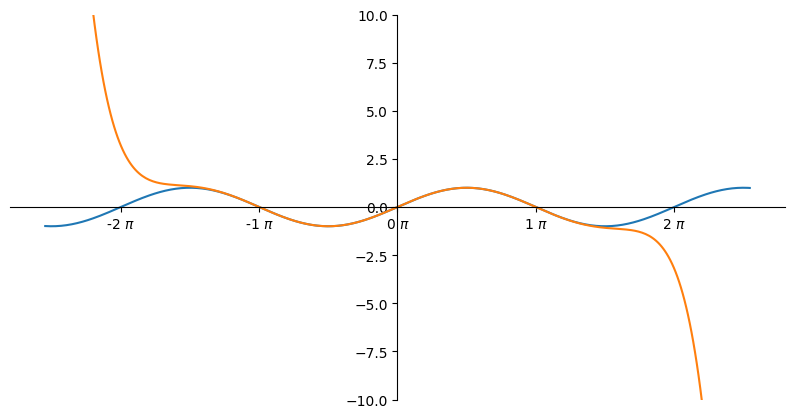

In [50]:
fig, ax = plt.subplots(figsize=(10,5))
xs = np.linspace(-8,8,400)
ax.set_ylim(-10,10)
ax.plot(xs/np.pi, np.sin(xs), label=r'$\sin(x)$')
ax.plot(xs/np.pi, s_fun(xs), label='Taylor')
use_pi_ticks(ax)
fix_axes(ax)

In [62]:
def T(n):
    return sp.series(sp.sin(x),x,0,n).removeO()

def T_fun(n):
    return sp.lambdify(x, T(n), 'numpy')

def show_T(n, R, L=10):
    fig, ax = plt.subplots(figsize=(10,5))
    xs = np.linspace(-R,R,400)
    ax.set_ylim(-L,L)
    ax.plot(xs/np.pi, np.sin(xs), label=r'$\sin(x)$')
    ax.plot(xs/np.pi, T_fun(n)(xs), label='Taylor')
    use_pi_ticks(ax)
    fix_axes(ax)


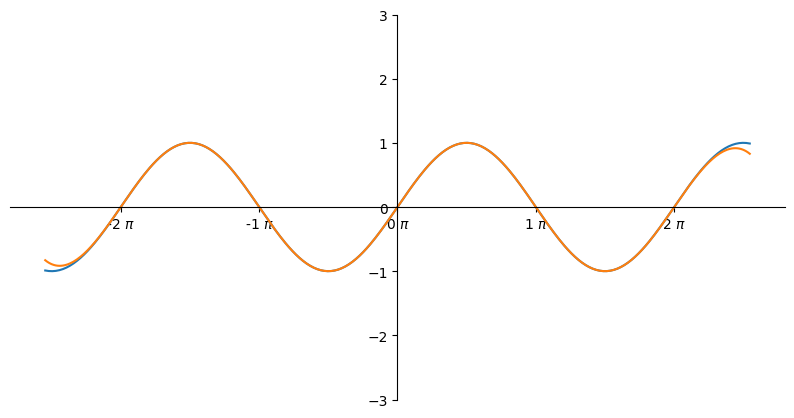

In [63]:
show_T(20,8,3)

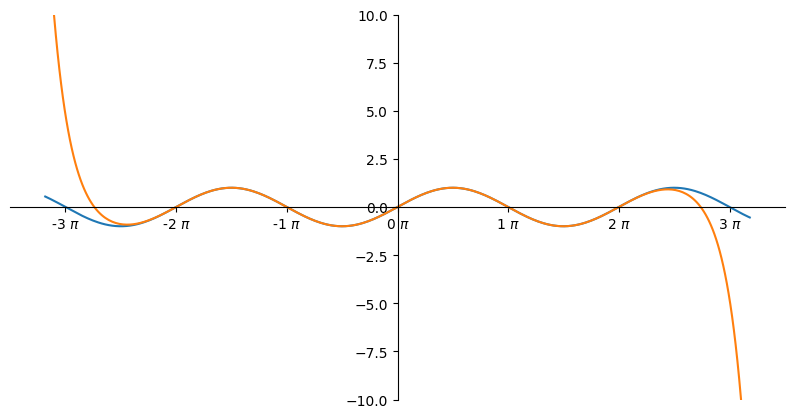

In [57]:
show_T(20,10)

<Axes: >

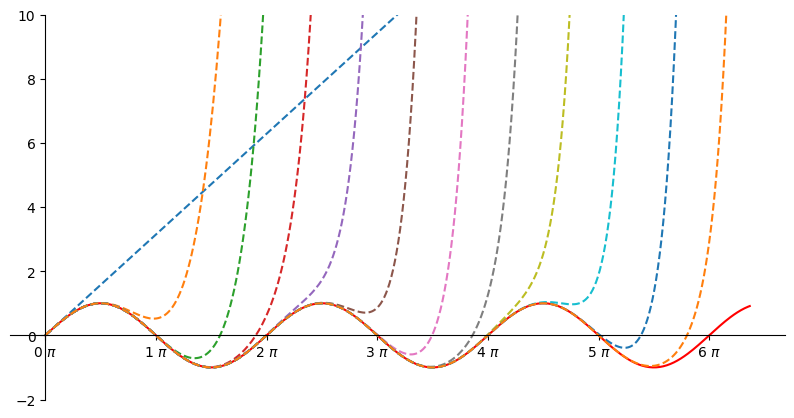

In [65]:
fig, ax = plt.subplots(figsize=(10,5))
xs = np.linspace(0,20,400)
ax.set_ylim(-2,10)
ax.plot(xs/np.pi, np.sin(xs), color='red')
for n in range(2,48,4):
    ax.plot(xs/np.pi, T_fun(n)(xs),linestyle='--')
use_pi_ticks(ax)
fix_axes(ax)


<Axes: >

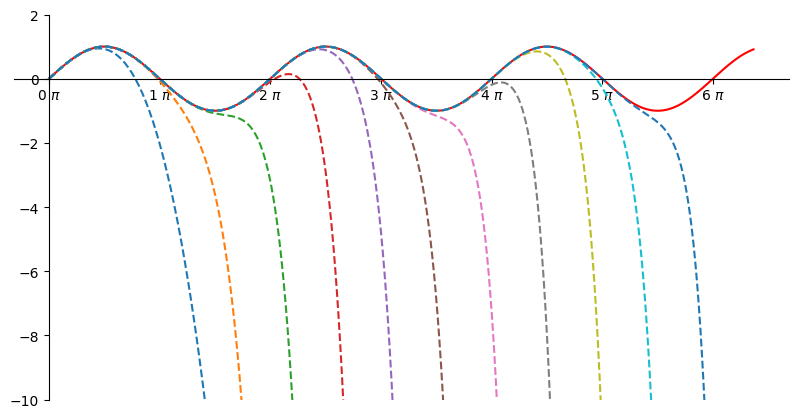

In [66]:
fig, ax = plt.subplots(figsize=(10,5))
xs = np.linspace(0,20,400)
ax.set_ylim(-10,2)
ax.plot(xs/np.pi, np.sin(xs), color='red')
for n in range(4,48,4):
    ax.plot(xs/np.pi, T_fun(n)(xs),linestyle='--')
use_pi_ticks(ax)
fix_axes(ax)


In [67]:
def R(n):
    return sp.series(sp.cos(x),x,0,n).removeO()

def R_fun(n):
    return sp.lambdify(x, R(n), 'numpy')



In [70]:
sp.expand(T(10)**2 + R(10)**2)

x**18/131681894400 - x**16/2090188800 + x**14/60963840 - x**12/4354560 + x**10/1814400 + 1

<Axes: >

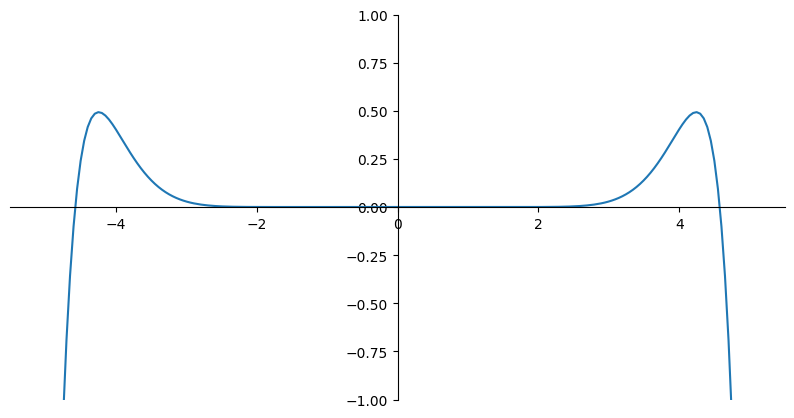

In [75]:
xs = np.linspace(-5,5,200)
err = 1 - T_fun(10)(xs)**2 - R_fun(10)(xs)**2
fig, ax = plt.subplots(figsize=(10,5))
ax.set_ylim(-1,1)
ax.plot(xs, err)
fix_axes(ax)

In [76]:
del x, s, s_fun, fig, ax, xs, T, T_fun, show_T, R, R_fun, err

Exercise 1.3

Here we consider the Taylor series for $y=\frac{x(1+x)}{(1-x)^3}$.

In [9]:
x = sp.symbols('x', real=True)
y = x*(1+x)/(1-x)**3
y_series = sp.series(y,x,0,11)
display(Latex("$y=" + sp.latex(y) + "\\approx " + sp.latex(y_series) + "$"))

<IPython.core.display.Latex object>

It seems clear from the above that $y=\sum_{n=1}^\infty n^2x^n$ (at least when $|x|<1$).  We can check this as follows.

In [12]:
n = sp.symbols('n', integer=True)
y1 = sp.Sum(n**2*x**n, (n, 0, sp.oo)).doit()
display(y1)
y2 = y1.args[0][0]
display(y2)
display(sp.simplify(y - y2))

Piecewise((x*(-x - 1)/(x - 1)**3, Abs(x) < 1), (Sum(n**2*x**n, (n, 0, oo)), True))

x*(-x - 1)/(x - 1)**3

0

In [13]:
del x, y, y_series, n, y1, y2

Exercise 1.4

Here we have the 12th order Taylor series of $\sin(x)$ around $x=\pi/2$.  Because $\sin(\pi/2+t)=\cos(t)$, this has the same coefficients as the Taylor series of $\cos(t)$ around $t=0$.

In [87]:
x = sp.symbols('x', real=True)
f_series = sp.series(sp.sin(x),x,sp.pi/2,12)
display(f_series)
g_series = sp.series(sp.cos(x),x,0,12)
display(g_series)
g_series.removeO().subs({x : x - sp.pi/2}) - f_series.removeO()


1 - (x - pi/2)**2/2 + (x - pi/2)**4/24 - (x - pi/2)**6/720 + (x - pi/2)**8/40320 - (x - pi/2)**10/3628800 + O((x - pi/2)**12, (x, pi/2))

1 - x**2/2 + x**4/24 - x**6/720 + x**8/40320 - x**10/3628800 + O(x**12)

0

In [88]:
del x, f_series, g_series

Exercise 2.1

Here we evaluate $\cos(\ln(\pi+20))$ to 20 decimal places.  (It is very small, but that is just a coincidence.)

In [15]:
mpmath.mp.dps = 20
print(1 + mpmath.cos(mpmath.log(mpmath.pi + 20)))

7.5631986690063713859e-10


Exercise 2.2

Here we calculate $f(f(f(-1/4)))$, where $f(x)=x^2-29/16$.  We find that the answer is just $-1/4$ again (which is an interesting example in the theory of the Mandelbrot set).

In [16]:
x = sp.symbols('x')
f = lambda x: x*x - sp.Rational(29,16)

In [17]:
x0 = sp.Rational(-1,4)
x1 = f(x0)
x2 = f(x1)
x3 = f(x2)
print([x0,x1,x2,x3])

[-1/4, -7/4, 5/4, -1/4]


In [94]:
del x, f, x0, x1, x2, x3

Exercise 2.3

In [ ]:
x = sp.symbols('x')
a = (1+x)**5-3*(1+x)**4+5*(1+x)**3-3*(1+x)**2+3*(1+x)+3
display(Latex("$a=" + sp.latex(a) + "$"))
b = (7*x**2-6*x-x**8)/(x-1)**2
display(b)

3*x + (x + 1)**5 - 3*(x + 1)**4 + 5*(x + 1)**3 - 3*(x + 1)**2 + 6

(-x**8 + 7*x**2 - 6*x)/(x - 1)**2

In [100]:
display(sp.simplify(a))
display(sp.factor(b))
display(sp.simplify(a*x + b))

x**5 + 2*x**4 + 3*x**3 + 4*x**2 + 5*x + 6

-x*(x**5 + 2*x**4 + 3*x**3 + 4*x**2 + 5*x + 6)

0

In [101]:
del x, a, b

Exercise 2.4

In [102]:
x = sp.symbols('x')
y = ((x**12-1)*(x**2-1)/((x**6-1)*(x**4-1)))**(10)
display(y)

(x**2 - 1)**10*(x**12 - 1)**10/((x**4 - 1)**10*(x**6 - 1)**10)

In [105]:
display(sp.factor(y))

(x**4 - x**2 + 1)**10

In [107]:
sp.expand(sp.factor(y)).coeff(x,6)

-210

In [108]:
del x, y

Exercise 2.5

In [110]:
x, y, z = sp.symbols('x y z')

sp.solve([
 sp.Eq(x**2 + y**2 + z**2, 9),
 sp.Eq((x-1)**2 + (y-1)**2 + (z-1)**2,2),
 sp.Eq(4*x**2+y*z,2*x*y+2*x*z)
],[x,y,z])


[(1, 2, 2), (8/7, 11/7, 16/7), (8/7, 16/7, 11/7)]

In [111]:
del x, y, z

Exercise 2.6

Union(ImageSet(Lambda(_n, 2*_n*pi + 4*pi/3), Integers), ImageSet(Lambda(_n, 2*_n*pi + 2*pi/3), Integers), ImageSet(Lambda(_n, 2*_n*pi + 5*pi/3), Integers), ImageSet(Lambda(_n, 2*_n*pi + pi/3), Integers))

<Axes: >

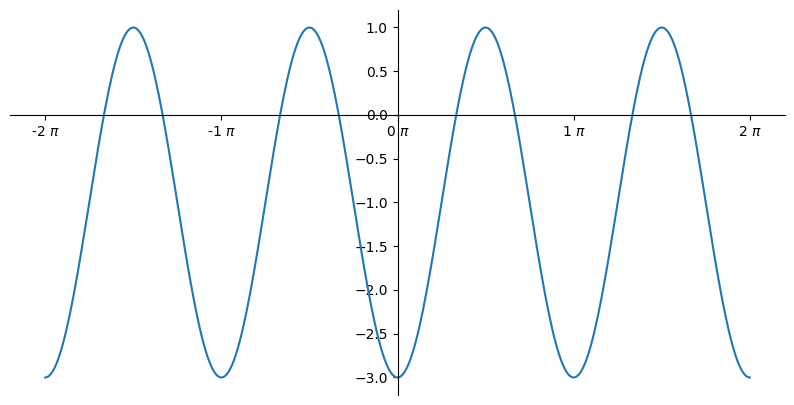

In [115]:
theta = sp.symbols('theta')
f = sp.sin(theta)**2-3*sp.cos(theta)**2
display(sp.solveset(f))
f_fun = sp.lambdify(theta, f, 'numpy')
theta = np.linspace(-2*np.pi,2*np.pi,400)
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(theta/np.pi, f_fun(theta))
use_pi_ticks(ax)
fix_axes(ax)

In [116]:
del theta, f, f_fun

Exercise 2.7

In [127]:
x, y = sp.symbols('x y', real=True, positive=True)
x0, y0 = sp.solve([x**2-y**2-1,2*x*y-1],[x,y])[0]
x0 = sp.simplify(x0)
y0 = sp.simplify(y0)
display(x0)
display(y0)

sqrt(-1 + sqrt(2))*(sqrt(2) + 2)/2

sqrt(-2 + 2*sqrt(2))/2

In [128]:
del x, y, x0, y0

Exercise 2.8

In [129]:
sc.optimize.root_scalar(lambda x: x - np.log(x+20),x0=3)

      converged: True
           flag: converged
 function_calls: 6
     iterations: 3
           root: 3.141633302801037

In [19]:
x = [1,2,3]
y = x.copy()
y.append(99)
print(x)

[1, 2, 3]


In [20]:
x.insert(0,999)
print(x)

[999, 1, 2, 3]
